## Diamond Price Prediction using Random Forest Regression

## Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

## Load Dataset

In [16]:
df = pd.read_csv("diamonds.csv")

## View Dataset

In [17]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [19]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [20]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

## Data Preprocessing

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

df.drop(columns=["Unnamed: 0"], axis=1, inplace=True)

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


## Train-Test Split

In [33]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

In [36]:
model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 15,
    min_samples_split = 5,
    min_samples_leaf = 2,
    random_state = 42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Prediction

In [37]:
y_pred = model.predict(X_test)

## Model Evaluation

In [52]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.4f}")
print(f"Mean Squared Error : {mse:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Mean Absolute Error : 268.9379
Mean Squared Error : 290181.0462
Root Mean Squared Error : 538.6846
R² Score : 0.9817


## Comparison Actual vs Predicted Price

In [57]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Difference
1388,559,547.664447,11.335553
50052,2201,2374.385101,-173.385101
41645,1238,1178.524196,59.475804
42377,1304,1255.508232,48.491768
17244,6901,9612.164467,-2711.164467
1608,3011,4087.105101,-1076.105101
46398,1765,1771.625451,-6.625451
45493,1679,1811.740620,-132.740620
49385,2102,2115.557370,-13.557370
10460,4789,5406.980658,-617.980658


## Feature Importance

In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,carat,0.632408
1,cut,0.001111
2,color,0.028200
3,clarity,0.065697
4,depth,0.002370
5,table,0.001636
6,x,0.004117
7,y,0.259879
8,z,0.004580


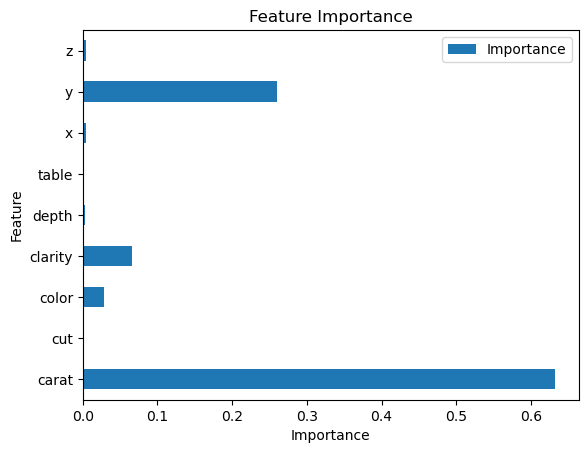

In [73]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.savefig("images/feature_importance")
plt.show()

## Data Visualization - Scatter Plot

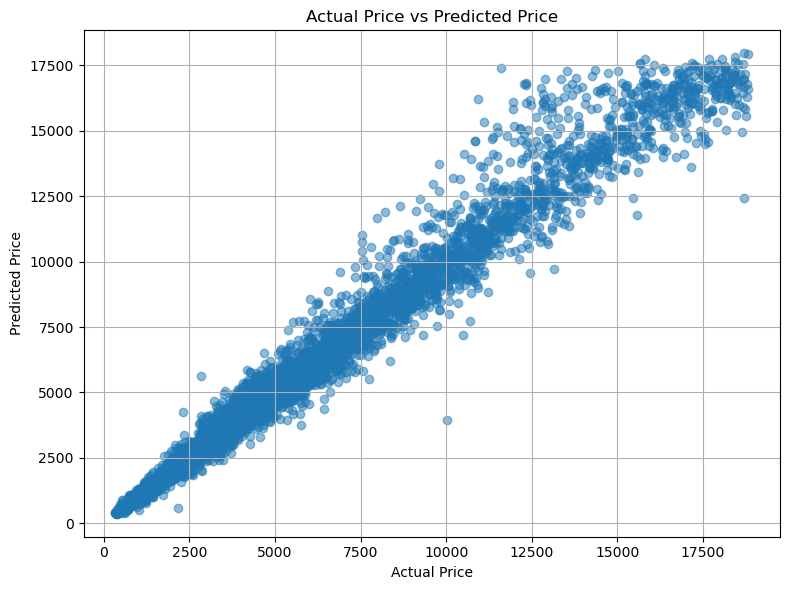

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(True)
plt.tight_layout()

plt.show()

## Conclusion

The Random Forest Regression model was successfully used to predict diamond prices. 

It achieved an MAE of 268.9379, MSE of 290181.0462, RMSE of 538.6846, and an R² Score of 0.9817, indicating best predictive performance. 

Overall, the model captured the relationship between the input features and diamond prices effectively, making it suitable for this prediction task.